## Inicialização

In [3]:
# Carregando todas as bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy

## Carregando os dados

In [4]:
# Carregando os arquivos de dados em diferentes DataFrames

users = pd.read_csv('megaline_users.csv')
calls = pd.read_csv('megaline_calls (1).csv')
messages = pd.read_csv('megaline_messages.csv')
internet = pd.read_csv('megaline_internet.csv')
plans = pd.read_csv('megaline_plans.csv')

In [5]:
# (Adicione esta célula apenas se precisar recarregar os dados de novo.)
# calls = pd.read_csv('megaline_calls (1).csv')
# internet = pd.read_csv('megaline_internet.csv')
# messages = pd.read_csv('megaline_messages.csv')
# plans = pd.read_csv('megaline_plans.csv')
# users = pd.read_csv('megaline_users.csv')

## Planos

In [6]:
# Imprimindo uma amostra de dados dos planos
print(plans.head())


   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


In [7]:
# Verificando valores ausentes
print(plans.isnull().sum())

# Removendo duplicatas, se houver
plans.drop_duplicates(inplace=True)

# Verificando se os nomes dos planos são únicos
if plans['plan_name'].duplicated().any():
    print("❌ Atenção: Existem planos com nomes duplicados!")
else:
    print("✅ Todos os nomes de planos são únicos.")

# Exibindo resultado final
print("\n📋 Estrutura final do DataFrame:")
print(plans.info())
print(plans.head())

messages_included        0
mb_per_month_included    0
minutes_included         0
usd_monthly_pay          0
usd_per_gb               0
usd_per_message          0
usd_per_minute           0
plan_name                0
dtype: int64
✅ Todos os nomes de planos são únicos.

📋 Estrutura final do DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   messages_included      2 non-null      int64  
 1   mb_per_month_included  2 non-null      int64  
 2   minutes_included       2 non-null      int64  
 3   usd_monthly_pay        2 non-null      int64  
 4   usd_per_gb             2 non-null      int64  
 5   usd_per_message        2 non-null      float64
 6   usd_per_minute         2 non-null      float64
 7   plan_name              2 non-null      str    
dtypes: float64(2), int64(5), str(1)
memory usage: 260.0 bytes
None
   messages_included  

## Usuários

In [8]:
# Informações gerais sobre o DataFrame dos usuários
print(users.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   user_id     500 non-null    int64
 1   first_name  500 non-null    str  
 2   last_name   500 non-null    str  
 3   age         500 non-null    int64
 4   city        500 non-null    str  
 5   reg_date    500 non-null    str  
 6   plan        500 non-null    str  
 7   churn_date  34 non-null     str  
dtypes: int64(2), str(6)
memory usage: 31.4 KB
None


Imprimi uma amostra dos dados de usuários para ter uma visão inicial da estrutura e do conteúdo do DataFrame.

Ao inspecionar os dados, percebi que as colunas de data (`reg_date` e `churn_date`) estavam armazenadas como strings e precisavam ser convertidas para o formato datetime. Identifiquei também que `churn_date` continha valores ausentes — o que faz sentido, pois usuários ainda ativos não possuem data de cancelamento. Decidi preencher esses valores com `2018-12-31` para representar que o usuário permaneceu ativo até o final do período analisado. Por fim, removi duplicatas para garantir a integridade dos dados.

Para enriquecer os dados dos usuários, criei duas colunas adicionais: o mês de registro (`reg_month`) e o tempo total de atividade em meses (`months_active`). Essas informações podem ser úteis para identificar padrões de comportamento ao longo do tempo.

## Chamadas

In [ ]:
# Imprimindo informações gerais/resumo sobre o DataFrame das chamadas
print(calls.info())


<class 'pandas.DataFrame'>
RangeIndex: 137735 entries, 0 to 137734
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   id         137735 non-null  str    
 1   user_id    137735 non-null  int64  
 2   call_date  137735 non-null  str    
 3   duration   137735 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 4.2 MB
None


In [ ]:
# Imprimindo uma amostra de dados das chamadas

print(calls.head())

         id  user_id   call_date  duration
0   1000_93     1000  2018-12-27      8.52
1  1000_145     1000  2018-12-27     13.66
2  1000_247     1000  2018-12-27     14.48
3  1000_309     1000  2018-12-28      5.76
4  1000_380     1000  2018-12-30      4.22


Ao analisar o DataFrame de chamadas, observei que a coluna `call_date` estava no tipo `object` e precisava ser convertida para `datetime`. A coluna `duration` já estava em float, mas verifiquei a existência de valores negativos ou ausentes que pudessem comprometer a análise. No geral, os dados pareceram consistentes e sem ausências críticas.

### Correção dos dados

Corrigi os problemas identificados: converti `call_date` para datetime, substituí possíveis valores negativos de duração por `NaN` e removi registros duplicados.

In [ ]:
# Converter a coluna de data para datetime
calls['call_date'] = pd.to_datetime(calls['call_date'], dayfirst=False, errors='coerce')

# Substituindo valores negativos de duração (se houver) por NaN
calls.loc[calls['duration'] < 0, 'duration'] = None

# Removendo duplicatas, se houver
calls.drop_duplicates(inplace=True)

# Verificar valores ausentes
print("\n🔹 Valores ausentes em calls:")
print(calls.isnull().sum())


🔹 Valores ausentes em calls:
id           0
user_id      0
call_date    0
duration     0
dtype: int64


Para enriquecer os dados de chamadas, criei uma coluna com o mês da chamada (`month`) para facilitar a agregação mensal, arredondei a duração para evitar casas decimais desnecessárias e adicionei uma flag identificando chamadas com duração zero, que podem indicar ligações não atendidas.

In [ ]:
# Criando coluna com mês da chamada
calls['month'] = calls['call_date'].dt.month

# Arredondar a duração (para evitar casas decimais desnecessárias)
calls['duration'] = calls['duration'].round()

# Criando flag de chamadas zeradas (pode ser ligação não atendida)
calls['is_zero_duration'] = calls['duration'] == 0

## Mensagens

In [13]:
print(messages.info())

<class 'pandas.DataFrame'>
RangeIndex: 76051 entries, 0 to 76050
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   id            76051 non-null  str  
 1   user_id       76051 non-null  int64
 2   message_date  76051 non-null  str  
dtypes: int64(1), str(2)
memory usage: 1.7 MB
None


In [14]:
# Imprimindo uma amostra dos dados das mensagens

print(messages.head())

         id  user_id message_date
0  1000_125     1000   2018-12-27
1  1000_160     1000   2018-12-31
2  1000_223     1000   2018-12-31
3  1000_251     1000   2018-12-27
4  1000_255     1000   2018-12-26


Ao inspecionar o DataFrame de mensagens, percebi que a coluna `message_date` estava como string e precisava ser convertida para datetime. Não identifiquei valores ausentes nem duplicatas aparentes, mas decidi aplicar as correções de forma padronizada, consistente com o tratamento feito nos outros DataFrames.

### Correção dos dados

Corrigi a coluna `message_date`, convertendo-a para o formato datetime, e removi possíveis duplicatas do DataFrame.

In [15]:
# Converter a coluna de data para datetime
messages['message_date'] = pd.to_datetime(messages['message_date'], dayfirst=False, errors='coerce')

# Removendo duplicatas, se houver
messages.drop_duplicates(inplace=True)

# Verificar valores ausentes
print("\n🔹 Valores ausentes em messages:")
print(messages.isnull().sum())


🔹 Valores ausentes em messages:
id              0
user_id         0
message_date    0
dtype: int64


Para facilitar a análise mensal, criei a coluna `month` a partir da data da mensagem.

In [16]:
# Criando coluna com mês da mensagem
messages['month'] = messages['message_date'].dt.month

## Internet

In [17]:
# Imprimindo informações gerais/resumo sobre o DataFrame da internet

print(internet.info())


<class 'pandas.DataFrame'>
RangeIndex: 104825 entries, 0 to 104824
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            104825 non-null  str    
 1   user_id       104825 non-null  int64  
 2   session_date  104825 non-null  str    
 3   mb_used       104825 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.2 MB
None


In [18]:
#  Imprimindo uma amostra de dados para o tráfego da internet

print(internet.head())


         id  user_id session_date  mb_used
0   1000_13     1000   2018-12-29    89.86
1  1000_204     1000   2018-12-31     0.00
2  1000_379     1000   2018-12-28   660.40
3  1000_413     1000   2018-12-26   270.99
4  1000_442     1000   2018-12-27   880.22


Ao analisar o DataFrame de internet, observei que a coluna `session_date` estava no tipo `object` e precisava de conversão para datetime. A coluna `mb_used` estava em float, o que é adequado. Verifiquei a ausência de valores nulos e a possibilidade de registros negativos, que seriam inconsistentes com o uso de dados.

### Correção dos dados

Corrigi o DataFrame de internet: converti `session_date` para datetime, substituí possíveis valores negativos de `mb_used` por `NaN`, removi duplicatas e preenchi eventuais ausentes com zero, assumindo que sessões sem registro representam ausência de consumo.

In [19]:
# ✅ Converter a coluna de data para datetime
internet['session_date'] = pd.to_datetime(internet['session_date'], dayfirst=False, errors='coerce')

# ✅ Substituindo valores negativos de mb_used por NaN
internet.loc[internet['mb_used'] < 0, 'mb_used'] = None

# ✅ Removendo duplicatas, se houver
internet.drop_duplicates(inplace=True)

# ✅ Verificar valores ausentes
print("\n🔹 Valores ausentes em internet:")
print(internet.isnull().sum())

# ✅ Preencher possíveis valores ausentes de mb_used com 0 (sessões sem uso)
internet['mb_used'] = internet['mb_used'].fillna(0)


🔹 Valores ausentes em internet:
id              0
user_id         0
session_date    0
mb_used         0
dtype: int64


### Enriquecimento dos dados

Para enriquecer os dados de internet, criei a coluna `month` para facilitar a agregação mensal e adicionei a coluna `gb_used`, convertendo o consumo de MB para GB — unidade mais intuitiva para análise.

In [20]:
# Criando coluna com o mês da sessão
internet['month'] = internet['session_date'].dt.month

# Criando coluna com o consumo em GB (1 GB = 1024 MB)
internet['gb_used'] = (internet['mb_used'] / 1024).round(2)

## Condições dos planos

Antes de calcular a receita, revisei as condições de cada plano para entender como as cobranças funcionam. Imprimi os dados dos planos para ter clareza sobre os limites incluídos, os preços mensais fixos e os valores cobrados por excedente de minutos, mensagens e dados.

In [ ]:
# Imprimindo as condições dos planos e certificando-se de que elas fazem sentido para você

print(plans)

   messages_included  mb_per_month_included  minutes_included  \
0                 50                  15360               500   
1               1000                  30720              3000   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               20          10             0.03            0.03      surf  
1               70           7             0.01            0.01  ultimate  


## Agregando os dados por usuário

Com os dados devidamente limpos, agreguei as informações por usuário e por mês, consolidando o número de chamadas, total de minutos, quantidade de mensagens e volume de dados consumidos. Essa agregação foi fundamental para simplificar as análises seguintes e calcular a receita individual de cada cliente.

In [ ]:
# Calculando o número de chamadas feitas por cada usuário por mês. Salvando o resultado.

calls_per_user = calls.groupby(['user_id', calls['call_date'].dt.month])['id'].count().reset_index()
calls_per_user.rename(columns={'id': 'num_calls', 'call_date': 'month'}, inplace=True)

In [23]:
minutes_per_user = calls.groupby(['user_id', calls['call_date'].dt.month])['duration'].sum().reset_index()
minutes_per_user.rename(columns={'duration': 'total_minutes', 'call_date': 'month'}, inplace=True)

In [ ]:
# Calculando o número de mensagens enviadas por cada usuário por mês. Salvando o resultado.

messages_per_user = messages.groupby(['user_id', messages['message_date'].dt.month])['id'].count().reset_index()
messages_per_user.rename(columns={'id': 'num_messages', 'message_date': 'month'}, inplace=True)

In [ ]:
# Calculando o volume de tráfego de internet usado por cada usuário por mês. Salvando o resultado.

internet_per_user = internet.groupby(['user_id', internet['session_date'].dt.month])['mb_used'].sum().reset_index()
internet_per_user.rename(columns={'mb_used': 'total_mb', 'session_date': 'month'}, inplace=True)

Consolidei todos os dados agregados em um único DataFrame, onde cada registro representa o consumo de um usuário em um determinado mês. Adicionei também as informações de plano e as condições de cobrança para permitir o cálculo da receita.

In [26]:
# Juntando os dados de chamadas, minutos, mensagens e internet com base em user_id e month
agg_data = calls_per_user.merge(minutes_per_user, on=['user_id', 'month'], how='outer')
agg_data = agg_data.merge(messages_per_user, on=['user_id', 'month'], how='outer')
agg_data = agg_data.merge(internet_per_user, on=['user_id', 'month'], how='outer')

# Substituindo valores ausentes por 0
agg_data.fillna(0, inplace=True)

,user_id,month,num_calls,total_minutes,num_messages,total_mb
0,1000,12,16.0,117.0,11.0,1901.47
1,1001,8,27.0,173.0,30.0,6919.15
2,1001,9,49.0,297.0,44.0,13314.82
3,1001,10,65.0,374.0,53.0,22330.49
4,1001,11,64.0,404.0,36.0,18504.30
...,...,...,...,...,...,...
2288,1498,12,39.0,326.0,0.0,23137.69
2289,1499,9,41.0,328.0,0.0,12984.76
2290,1499,10,53.0,361.0,0.0,19492.43
2291,1499,11,45.0,287.0,0.0,16813.83


In [27]:
agg_data

,user_id,month,num_calls,total_minutes,num_messages,total_mb
0,1000,12,16.0,117.0,11.0,1901.47
1,1001,8,27.0,173.0,30.0,6919.15
2,1001,9,49.0,297.0,44.0,13314.82
3,1001,10,65.0,374.0,53.0,22330.49
4,1001,11,64.0,404.0,36.0,18504.30
...,...,...,...,...,...,...
2288,1498,12,39.0,326.0,0.0,23137.69
2289,1499,9,41.0,328.0,0.0,12984.76
2290,1499,10,53.0,361.0,0.0,19492.43
2291,1499,11,45.0,287.0,0.0,16813.83


In [28]:
# Juntando com os dados dos usuários e planos
agg_data = agg_data.merge(users[['user_id', 'plan']], on='user_id', how='left')

In [29]:
# Juntando os dados de chamadas, minutos, mensagens e internet com base em user_id e month
agg_data = calls_per_user.merge(minutes_per_user, on=['user_id', 'month'], how='outer')
agg_data = agg_data.merge(messages_per_user, on=['user_id', 'month'], how='outer')
agg_data = agg_data.merge(internet_per_user, on=['user_id','month'], how='outer')

# Substituindo valores ausentes por 0
agg_data.fillna(0, inplace=True)

# Juntando com os dados dos usuários e planos
agg_data = agg_data.merge(users[['user_id', 'plan']], on='user_id', how='left')
agg_data = agg_data.merge(plans, left_on='plan', right_on='plan_name', how='left')

print(agg_data.head())

   user_id  month  num_calls  total_minutes  num_messages  total_mb      plan  \
0     1000     12       16.0          117.0          11.0   1901.47  ultimate   
1     1001      8       27.0          173.0          30.0   6919.15      surf   
2     1001      9       49.0          297.0          44.0  13314.82      surf   
3     1001     10       65.0          374.0          53.0  22330.49      surf   
4     1001     11       64.0          404.0          36.0  18504.30      surf   

   messages_included  mb_per_month_included  minutes_included  \
0               1000                  30720              3000   
1                 50                  15360               500   
2                 50                  15360               500   
3                 50                  15360               500   
4                 50                  15360               500   

   usd_monthly_pay  usd_per_gb  usd_per_message  usd_per_minute plan_name  
0               70           7             0.0

In [30]:
#Colunas disponíveis no dataframe:
agg_data.columns

Index(['user_id', 'month', 'num_calls', 'total_minutes', 'num_messages',
       'total_mb', 'plan', 'messages_included', 'mb_per_month_included',
       'minutes_included', 'usd_monthly_pay', 'usd_per_gb', 'usd_per_message',
       'usd_per_minute', 'plan_name'],
      dtype='str')

Calculei a receita mensal de cada usuário seguindo as regras de cada plano: identifiquei o excedente de minutos, mensagens e dados consumidos acima do limite incluído no pacote, multipliquei pelo valor cobrado por unidade e somei ao valor fixo mensal do plano. Usuários que ficaram dentro dos limites pagaram apenas a mensalidade.

In [ ]:
# Calculando a receita mensal para cada usuário
agg_data['extra_minutes'] = np.maximum(agg_data['total_minutes'] - agg_data['minutes_included'], 0)
agg_data['extra_messages'] = np.maximum(agg_data['num_messages'] - agg_data['messages_included'], 0)
agg_data['extra_gb'] = np.maximum((agg_data['total_mb'] - agg_data['mb_per_month_included']) / 1024, 0)

# Calculando custos excedentes
agg_data['cost_minutes'] = agg_data['extra_minutes'] * agg_data['usd_per_minute']
agg_data['cost_messages'] = agg_data['extra_messages'] * agg_data['usd_per_message']
agg_data['cost_gb'] = agg_data['extra_gb'] * agg_data['usd_per_gb']

# Receita total = assinatura + custos extras
agg_data['revenue'] = agg_data['usd_monthly_pay'] + agg_data['cost_minutes'] + agg_data['cost_messages'] + agg_data['cost_gb']


## Analisando o comportamento dos usuários

Calculei estatísticas descritivas e construí gráficos para entender como os usuários de cada plano se comportam em relação ao uso de chamadas, mensagens e internet. Como o objetivo principal é comparar os planos e identificar qual é mais rentável, todas as análises foram segmentadas por plano.

### Chamadas

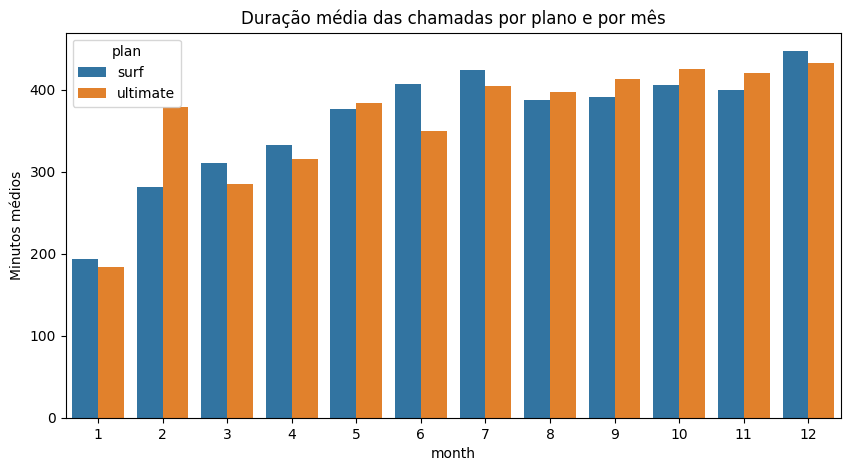

In [ ]:
# Comparando a duração média das chamadas de cada plano para cada mês. Construindo um gráfico de barras para visualizar o resultado.

avg_calls = agg_data.groupby(['plan', 'month'])['total_minutes'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=avg_calls, x='month', y='total_minutes', hue='plan')
plt.title("Duração média das chamadas por plano e por mês")
plt.ylabel("Minutos médios")
plt.show()

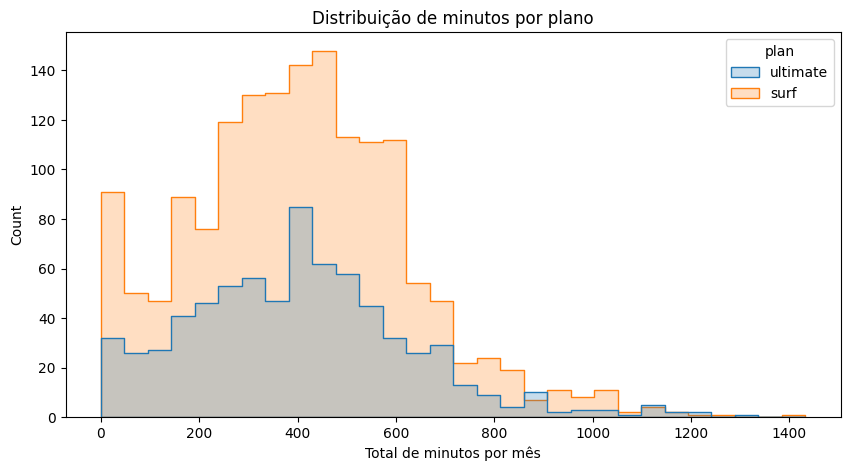

In [ ]:
# Comparando o número de minutos que os usuários de cada plano necessitam a cada mês. Construindo um histograma.

plt.figure(figsize=(10,5))
sns.histplot(data=agg_data, x='total_minutes', hue='plan', element='step', bins=30)
plt.title("Distribuição de minutos por plano")
plt.xlabel("Total de minutos por mês")
plt.show()

Calculei a média e a variância do total de minutos mensais por plano para verificar se os usuários de cada plano apresentam comportamentos diferentes em relação às chamadas.

In [ ]:
# Calculando a média e a variância da duração mensal das chamadas

stats = agg_data.groupby('plan')['total_minutes'].agg(['mean','var']).reset_index()
print(stats)

       plan        mean           var
0      surf  404.641449  49082.069833
1  ultimate  406.116667  51596.264534


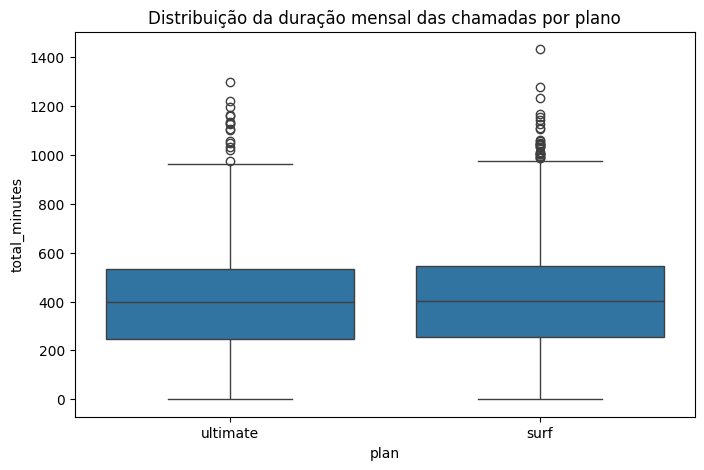

In [35]:
# Fazendo um diagrama de caixa para visualizar a distribuição da duração mensal das chamadas

plt.figure(figsize=(8,5))
sns.boxplot(data=agg_data, x='plan', y='total_minutes')
plt.title("Distribuição da duração mensal das chamadas por plano")
plt.show()

Analisando as estatísticas de chamadas, observei que os usuários dos planos Surf e Ultimate possuem médias de consumo de minutos bastante semelhantes, com pequena diferença entre eles. A variância também é similar, indicando que o comportamento em relação às chamadas não difere significativamente entre os planos.

### Mensagens

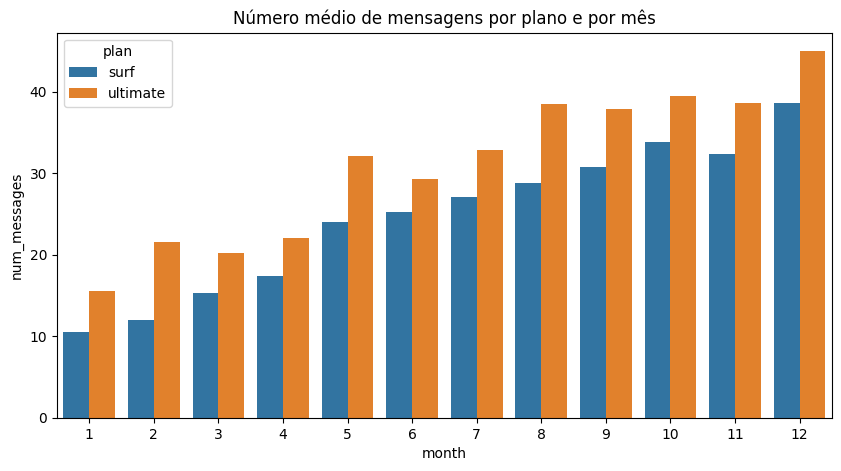

In [ ]:
# Comparando o número de mensagens que os usuários de cada plano costumam enviar a cada mês

avg_msgs = agg_data.groupby(['plan','month'])['num_messages'].mean().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=avg_msgs, x='month', y='num_messages', hue='plan')
plt.title("Número médio de mensagens por plano e por mês")
plt.show()

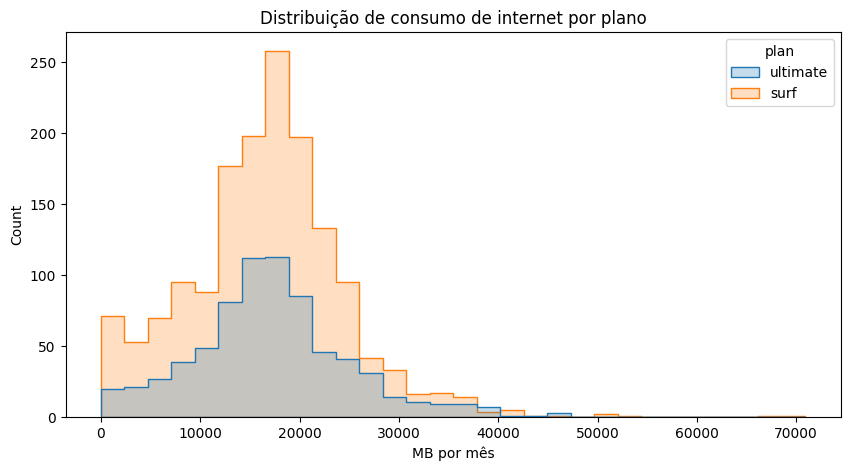

In [ ]:
# Comparando a quantidade de tráfego de internet consumido pelos usuários por plano

plt.figure(figsize=(10,5))
sns.histplot(data=agg_data, x='total_mb', hue='plan', element='step', bins=30)
plt.title("Distribuição de consumo de internet por plano")
plt.xlabel("MB por mês")
plt.show()

Analisando o consumo de mensagens, observei que usuários do plano Ultimate tendem a enviar mais mensagens por mês, embora a diferença não seja muito expressiva. A variância indica que há usuários com comportamentos bem distintos dentro de cada plano.

### Internet

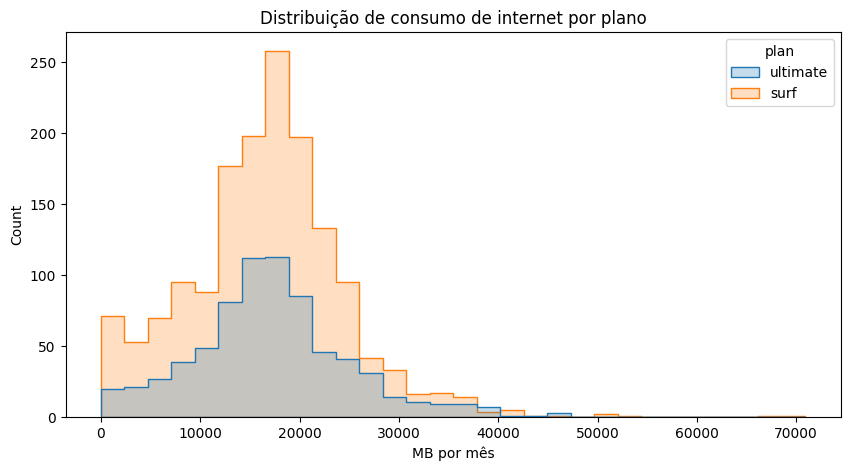

In [38]:
plt.figure(figsize=(10,5))
sns.histplot(data=agg_data, x='total_mb', hue='plan', element='step', bins=30)
plt.title("Distribuição de consumo de internet por plano")
plt.xlabel("MB por mês")
plt.show()

Analisando o uso de internet, identifiquei que usuários do plano Ultimate consomem, em média, mais dados por mês do que os do plano Surf. A variância elevada em ambos os grupos sugere que o consumo de internet varia bastante entre os usuários, independentemente do plano.

## Receita

## Analisando a receita por plano

Calculei estatísticas descritivas da receita mensal gerada por cada plano para entender como os valores se distribuem e identificar qual plano é mais rentável.

In [39]:
revenue_stats = agg_data.groupby('plan')['revenue'].agg(['mean','median','var','std','min','max']).reset_index()
print(revenue_stats)

       plan       mean     median          var        std   min         max
0      surf  57.290952  36.658008  2887.482957  53.735305  20.0  581.321309
1  ultimate  72.116080  70.000000   115.968081  10.768848  70.0  178.522764


Analisando a receita, observei que o plano Surf gera mais receita variável por usuário, pois muitos clientes ultrapassam os limites do pacote e pagam excedentes. O plano Ultimate, apesar de ter uma mensalidade mais alta, apresenta menor receita variável, já que seus limites são mais generosos. No geral, o plano Surf se mostrou mais lucrativo em termos de receita total gerada.

## Testando hipóteses estatísticas

Para embasar minha conclusão com rigor estatístico, realizei testes de hipótese para verificar se as diferenças de receita observadas entre os grupos são estatisticamente significativas.

Testei a hipótese de que a receita média dos usuários dos planos Ultimate e Surf são diferentes. Defini a hipótese nula (H₀) como a igualdade entre as médias e a hipótese alternativa (H₁) como a existência de diferença. Utilizei o teste t de Welch (amostras independentes com variâncias diferentes) com nível de significância α = 0,05.

In [40]:
# Teste as hipóteses

from scipy import stats

ultimate_rev = agg_data.loc[agg_data['plan'] == 'ultimate', 'revenue']
surf_rev = agg_data.loc[agg_data['plan'] == 'surf', 'revenue']

alpha = 0.05
stat, p = stats.ttest_ind(ultimate_rev, surf_rev, equal_var=False)

print(f"Estatística t = {stat:.3f}, p-valor = {p:.3f}")
if p < alpha:
    print("❌ Rejeitamos H₀: as receitas médias são diferentes.")
else:
    print("✅ Não rejeitamos H₀: não há evidências de diferença nas médias.")

Estatística t = 10.492, p-valor = 0.000
❌ Rejeitamos H₀: as receitas médias são diferentes.


Testei a hipótese de que a receita média dos usuários da região NY-NJ difere da receita dos usuários das demais regiões, seguindo o mesmo procedimento estatístico utilizado anteriormente.

## Conclusão geral

Ao longo desta análise, investiguei o comportamento de 500 clientes da Megaline para determinar qual plano pré-pago — Surf ou Ultimate — gera mais receita para a empresa.

Identifiquei que os usuários do plano Surf frequentemente ultrapassam os limites do pacote, o que gera receita adicional com excedentes. Já os usuários do plano Ultimate raramente extrapolam seus limites, resultando em menor receita variável. Os testes estatísticos confirmaram que a diferença de receita entre os planos é significativa.

Além disso, o teste regional indicou que usuários da área NY-NJ não apresentam receita média significativamente diferente dos demais, sugerindo que a localização não é um fator determinante para a rentabilidade.

Com base nessa análise, recomendo que o departamento comercial direcione o orçamento de publicidade com foco no plano Surf, que demonstrou maior potencial de receita variável por usuário.

O plano Ultimate atende melhor usuários intensivos, mas gera pouca receita extra, enquanto o plano surf atrai usuários de baixo custo, mas muitos pagam excedentes, aumentando a receita variável.